In [1]:
import sys
import os

os.chdir('../')
os.getcwd()

'/Users/lbrice1/repos/ai_cheme_examples'

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import hdbscan
import pacmap

from sklearn.preprocessing import MinMaxScaler
from scipy import stats

In [ ]:
data = pd.read_csv('data/NOX.csv', header=None)

data = data.sort_values(by=[0])

data[2] = np.random.normal(3.99, 1.99,size=150)

data_mean = data[1].mean()

print(data_mean, data[1].std())

print(data)

3.9895358649789032 2.178858710089031
              0         1         2
1      0.000000  3.468354  3.158085
0      1.196013  5.012658  6.261239
146    3.289037  2.835443  2.351472
145    4.485050  1.443038  3.499796
2      5.382060  5.012658  2.061147
..          ...       ...       ...
137  173.720930  5.645570  3.824461
138  174.019934  3.215190  4.037134
139  175.813953  3.696203  4.804172
140  176.710963  1.772152  6.721656
141  179.401993  3.544304  6.434656

[150 rows x 3 columns]


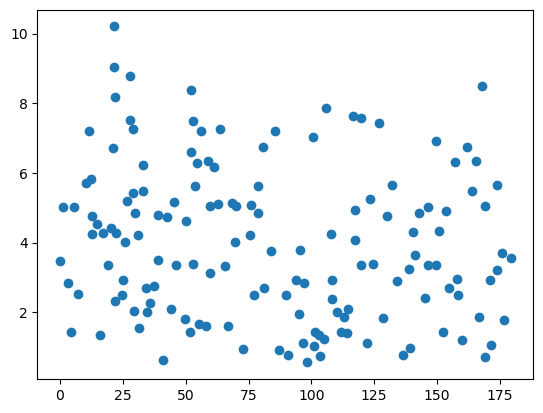

In [4]:
plt.scatter(data[0], data[1])

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


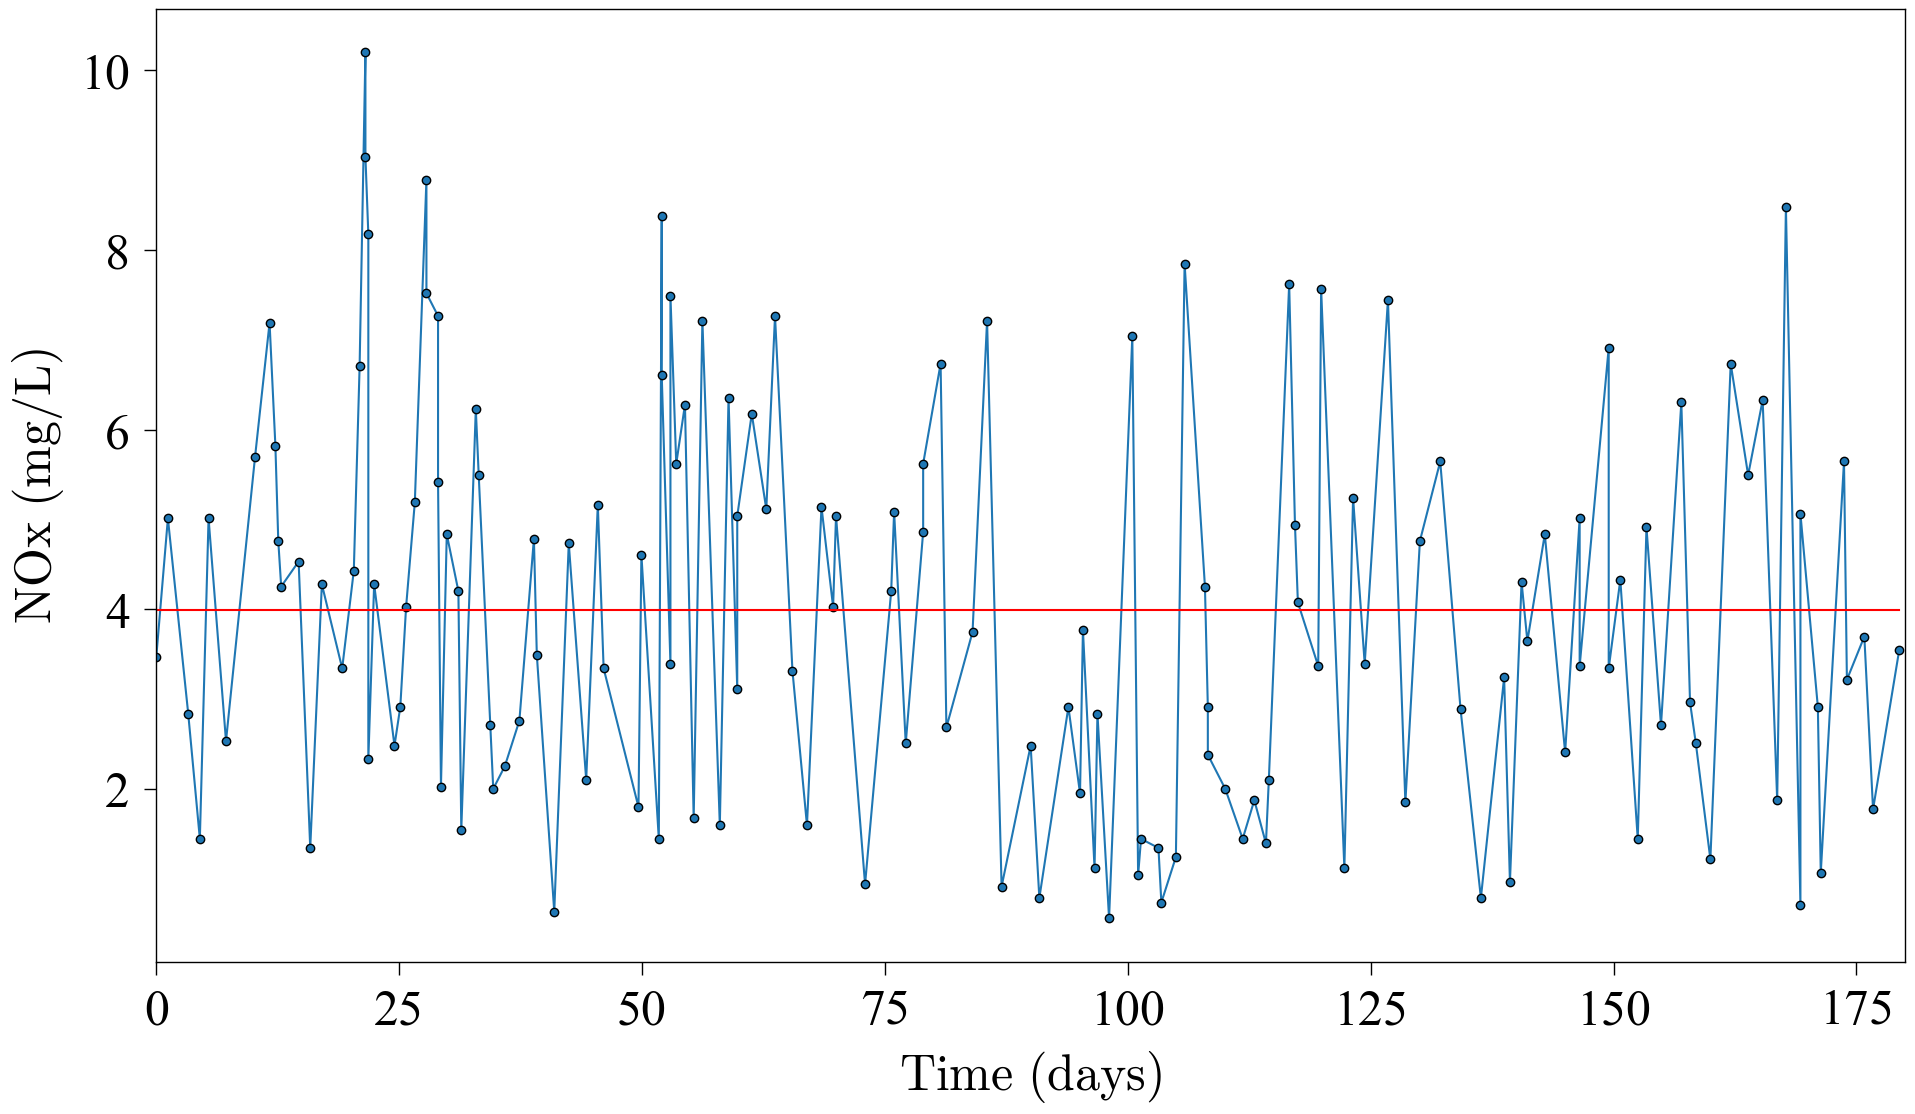

In [14]:
fig = plt.figure(figsize=(20, 12))
axs0 = fig.add_subplot(1, 1, 1)

axs0.plot(data[0], data[1], marker='o', markeredgecolor='k')
axs0.plot([min(data[0]), max(data[0])], [data[1].mean(), data[1].mean()], c = 'r')


axs0.set_xlabel(r'$ \rm Time\ (days)$', labelpad = 10, fontsize='x-large')
axs0.set_ylabel(r'$ \rm NOx\ (mg/L)$', labelpad = 10, fontsize='x-large')

axs0.tick_params(direction='out',
                    pad=10,
                    length=9,
                    width=1,
                    labelsize='x-large')

axs0.tick_params(which='minor',
                    direction='out',
                    pad=10,
                    length=5,
                    width=1,
                    labelsize='x-large')

for ax in ['top', 'bottom', 'left', 'right']:
    axs0.spines[ax].set_linewidth(1)

axs0.set_xlim(0,180)

plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman"
                                ] + plt.rcParams["font.serif"]
plt.rcParams['font.size']=35
plt.rcParams['axes.linewidth'] = 1 

plt.legend(frameon = False)
plt.tight_layout()

plt.savefig('figures/example-2-0.png', dpi = 300)

plt.show()

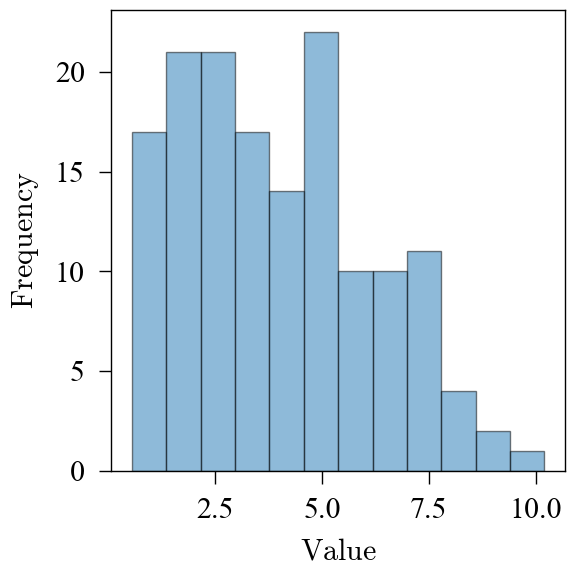

In [6]:
fig = plt.figure(figsize=(6, 6))

axs0 = data[1].plot.hist(bins=12, alpha=0.5, edgecolor = 'k')

axs0.set_xlabel(r'$ \rm Value$', labelpad = 10, fontsize='x-large')
axs0.set_ylabel(r'$ \rm Frequency$', labelpad = 10, fontsize='x-large')

axs0.tick_params(direction='out',
                    pad=10,
                    length=9,
                    width=1,
                    labelsize='x-large')

axs0.tick_params(which='minor',
                    direction='out',
                    pad=10,
                    length=5,
                    width=1,
                    labelsize='x-large')

for ax in ['top', 'bottom', 'left', 'right']:
    axs0.spines[ax].set_linewidth(1)

plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman"
                                ] + plt.rcParams["font.serif"]
plt.rcParams['font.size']=15
plt.rcParams['axes.linewidth'] = 1 

#plt.legend(frameon = False)
plt.tight_layout()

plt.savefig('figures/example-2-0_1.png', dpi = 300)

plt.show()

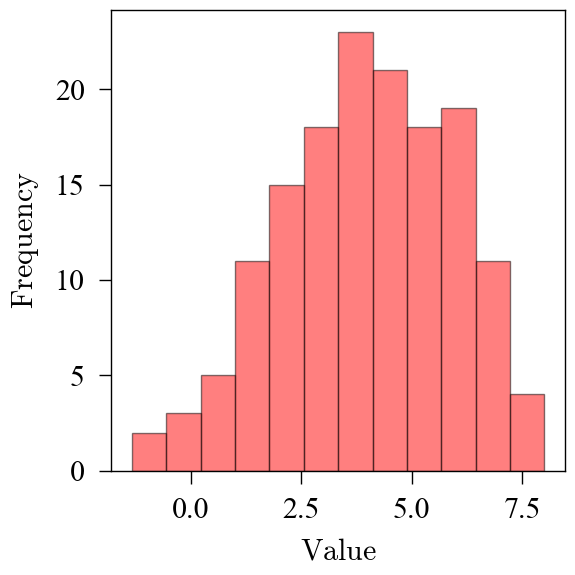

In [7]:
fig = plt.figure(figsize=(6, 6))

axs0 = data[2].plot.hist(bins=12, alpha=0.5, edgecolor = 'k', color = 'r')

axs0.set_xlabel(r'$ \rm Value$', labelpad = 10, fontsize='x-large')
axs0.set_ylabel(r'$ \rm Frequency$', labelpad = 10, fontsize='x-large')

axs0.tick_params(direction='out',
                    pad=10,
                    length=9,
                    width=1,
                    labelsize='x-large')

axs0.tick_params(which='minor',
                    direction='out',
                    pad=10,
                    length=5,
                    width=1,
                    labelsize='x-large')

for ax in ['top', 'bottom', 'left', 'right']:
    axs0.spines[ax].set_linewidth(1)

plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman"
                                ] + plt.rcParams["font.serif"]
plt.rcParams['font.size']=15
plt.rcParams['axes.linewidth'] = 1 

#plt.legend(frameon = False)
plt.tight_layout()

plt.savefig('figures/example-2-0_1.png', dpi = 300)

plt.show()

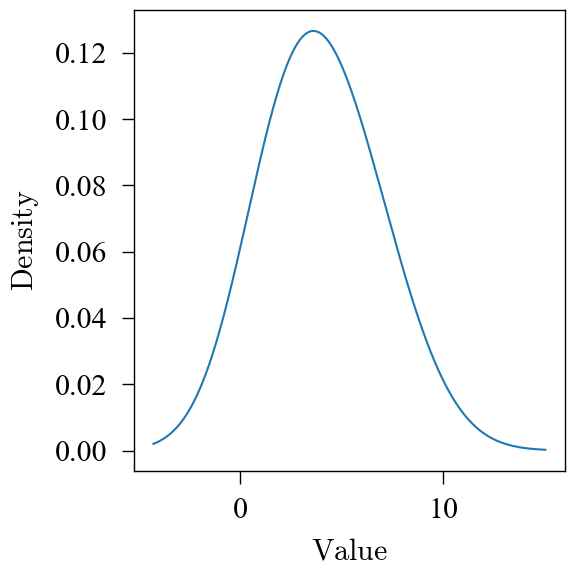

In [8]:
fig = plt.figure(figsize=(6, 6))
axs0 = data[1].plot.kde(bw_method=1)

axs0.set_xlabel(r'$ \rm Value$', labelpad = 10, fontsize='x-large')
axs0.set_ylabel(r'$ \rm Density$', labelpad = 10, fontsize='x-large')

axs0.tick_params(direction='out',
                    pad=10,
                    length=9,
                    width=1,
                    labelsize='x-large')

axs0.tick_params(which='minor',
                    direction='out',
                    pad=10,
                    length=5,
                    width=1,
                    labelsize='x-large')

for ax in ['top', 'bottom', 'left', 'right']:
    axs0.spines[ax].set_linewidth(1)

plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman"
                                ] + plt.rcParams["font.serif"]
plt.rcParams['font.size']=15
plt.rcParams['axes.linewidth'] = 1 

#plt.legend(frameon = False)
plt.tight_layout()

plt.savefig('figures/example-2-0_2.png', dpi = 300)

plt.show()

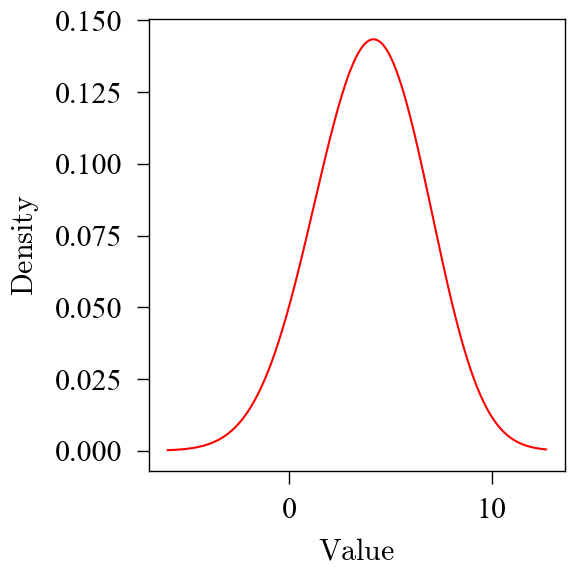

In [9]:
fig = plt.figure(figsize=(6, 6))
axs0 = data[2].plot.kde(bw_method=1, color = 'r')

axs0.set_xlabel(r'$ \rm Value$', labelpad = 10, fontsize='x-large')
axs0.set_ylabel(r'$ \rm Density$', labelpad = 10, fontsize='x-large')

axs0.tick_params(direction='out',
                    pad=10,
                    length=9,
                    width=1,
                    labelsize='x-large')

axs0.tick_params(which='minor',
                    direction='out',
                    pad=10,
                    length=5,
                    width=1,
                    labelsize='x-large')

for ax in ['top', 'bottom', 'left', 'right']:
    axs0.spines[ax].set_linewidth(1)

plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman"
                                ] + plt.rcParams["font.serif"]
plt.rcParams['font.size']=15
plt.rcParams['axes.linewidth'] = 1 

#plt.legend(frameon = False)
plt.tight_layout()

plt.savefig('figures/example-2-0_2.png', dpi = 300)

plt.show()